In [35]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Load the dataset
df = pd.read_csv('github_features_clean.csv')

# 2. Separate features (X) and target (y)
X = df.drop(columns=['stargazers_count'])
y = df['stargazers_count']

y = np.log1p(y)

# 3. Split into training and testing sets (80% train, 20% test)
# random_state ensures reproducibility across different runs
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (800, 6)
Testing data shape: (200, 6)


In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# 1. Check if we need to scale
print("--- Summary Statistics Before Scaling ---")
# Select only the continuous numerical columns
continuous_cols = ['topic_count', 'forks_count_log', 'open_issues_count_log', 'days_since_last_push_log']
print(X_train[continuous_cols].describe().loc[['mean', 'std', 'min', 'max']])

# Let's write a quick logical check to see if ranges/variances vary significantly
std_devs = X_train[continuous_cols].std()
if std_devs.max() / std_devs.min() > 2:
    print("\n[!] Conclusion: Standard deviations vary significantly between features. Scaling is highly recommended!")
else:
    print("\n[i] Conclusion: Features are on relatively similar scales, but we will scale them for consistency.")

# 2. Set up the Preprocessing Pipeline
# We want to scale continuous features but leave boolean features (has_projects, has_wiki) alone
boolean_cols = ['has_projects', 'has_wiki']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), continuous_cols),
        ('bool', 'passthrough', boolean_cols)
    ])

# 3. Fit the preprocessor on the training data and transform it
# (We only FIT on training data to prevent data leakage from the test set)
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

# Convert back to DataFrame just to display how it looks now
# Note: ColumnTransformer changes the column order, so we reconstruct it based on the transformer order
new_col_order = continuous_cols + boolean_cols
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=new_col_order, index=X_train.index)

print("\n--- First 3 rows of Preprocessed & Scaled Training Data ---")
display(X_train_scaled_df.head(3))

# 4. Verify the scaling worked
print("\n--- Summary Statistics After Scaling ---")
display(X_train_scaled_df[continuous_cols].describe().loc[['mean', 'std', 'min', 'max']].round(3))

--- Summary Statistics Before Scaling ---
      topic_count  forks_count_log  open_issues_count_log  \
mean      8.42625         8.742448               5.356359   
std       6.33816         0.925055               1.861530   
min       0.00000         2.079442               0.000000   
max      20.00000        11.607572              10.496345   

      days_since_last_push_log  
mean                  2.456175  
std                   2.038287  
min                   0.693147  
max                   7.766417  

[!] Conclusion: Standard deviations vary significantly between features. Scaling is highly recommended!

--- First 3 rows of Preprocessed & Scaled Training Data ---


,topic_count,forks_count_log,open_issues_count_log,days_since_last_push_log,has_projects,has_wiki
29,-0.067293,2.268540,-0.039323,1.963952,1.0,1.0
535,1.511438,-0.483948,0.767644,-0.865497,1.0,1.0
695,-0.225167,-0.932034,-1.356262,-0.865497,1.0,1.0



--- Summary Statistics After Scaling ---


,topic_count,forks_count_log,open_issues_count_log,days_since_last_push_log
mean,0.000,-0.000,-0.000,-0.000
std,1.001,1.001,1.001,1.001
min,-1.330,-7.207,-2.879,-0.865
max,1.827,3.099,2.763,2.607


Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1. Initialize the model
lr_model = LinearRegression()

# 2. Train (fit) the model on the scaled training data
lr_model.fit(X_train_scaled, y_train)

# 3. Make predictions on the unseen test data
lr_predictions = np.expm1(lr_model.predict(X_test_scaled))

# 4. Evaluate using R-squared
y_test_actual = np.expm1(y_test)
lr_r2 = r2_score(y_test_actual, lr_predictions)

print(f"Linear Regression R-squared: {lr_r2:.4f}")

Linear Regression R-squared: 0.3290


Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# 1. Initialize the model
rf_model = RandomForestRegressor(random_state=42)

# 2. Train the model
rf_model.fit(X_train_scaled, y_train)

# 3. Make predictions
rf_predictions = np.expm1(rf_model.predict(X_test_scaled))

# 4. Evaluate using R-squared
y_test_actual = np.expm1(y_test)
rf_r2 = r2_score(y_test_actual, rf_predictions)

print(f"Random Forest R-squared: {rf_r2:.4f}")

Random Forest R-squared: 0.2942


Gradient Boosting Regressor

In [39]:
from sklearn.ensemble import GradientBoostingRegressor

# 1. Initialize the model
gb_model = GradientBoostingRegressor(random_state=42)

# 2. Train the model
gb_model.fit(X_train_scaled, y_train)

# 3. Make predictions
gb_predictions = np.expm1(gb_model.predict(X_test_scaled))

# 4. Evaluate using R-squared
y_test_actual = np.expm1(y_test)
gb_r2 = r2_score(y_test_actual, gb_predictions)

print(f"Gradient Boosting R-squared: {gb_r2:.4f}")

Gradient Boosting R-squared: -0.0269


Linear Regression alpha tuning

In [50]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

print("--- Extensive Tuning: Ridge Regression ---")

param_grid_ridge = {
    'alpha': [0, 0.01, 0.1, 1.0, 10.0, 50.0, 100.0, 200.0, 500.0],
    'fit_intercept': [True, False],
    'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'saga']
}

grid_ridge = GridSearchCV(
    estimator=Ridge(), 
    param_grid=param_grid_ridge, 
    cv=5, 
    scoring='r2', 
    n_jobs=-1 
)

grid_ridge.fit(X_train_scaled, y_train)

y_test_actual = np.expm1(y_test)

best_ridge = grid_ridge.best_estimator_
ridge_r2_tuned = r2_score(y_test_actual, np.expm1(best_ridge.predict(X_test_scaled)))

print(f"Best Parameters: {grid_ridge.best_params_}")
print(f"Tuned Ridge R-squared: {ridge_r2_tuned:.4f}")

--- Extensive Tuning: Ridge Regression ---
Best Parameters: {'alpha': 10.0, 'fit_intercept': True, 'solver': 'svd'}
Tuned Ridge R-squared: 0.3278


Random Forest Hyperparameter Tuning

In [41]:
print("--- Extensive Tuning: Random Forest Regressor ---")

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 1.0]
}

grid_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42), 
    param_grid=param_grid_rf, 
    cv=5, 
    scoring='r2', 
    n_jobs=-1,
    verbose=1 # Added verbose so you can see the progress!
)

grid_rf.fit(X_train_scaled, y_train)

best_rf = grid_rf.best_estimator_
rf_r2_tuned    = r2_score(y_test_actual, np.expm1(best_rf.predict(X_test_scaled)))

print(f"Best Parameters: {grid_rf.best_params_}")
print(f"Tuned Random Forest R-squared: {rf_r2_tuned:.4f}")

--- Extensive Tuning: Random Forest Regressor ---
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Tuned Random Forest R-squared: 0.3463


GB Regressor Hyperparameter Tuning

In [42]:
print("--- Extensive Tuning: Gradient Boosting Regressor ---")

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

param_dist_gb = {
    'n_estimators': [500, 1000],       # Keep high, let learning_rate do the work
    'learning_rate': uniform(0.01, 0.19),
    'max_depth': randint(2, 6),
    'subsample': uniform(0.5, 0.5),    # Range: 0.5 to 1.0
    'min_samples_leaf': randint(1, 20),
    'max_features': ['sqrt', 0.7, 1.0]
}

random_gb = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_dist_gb,
    n_iter=60,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

random_gb.fit(X_train_scaled, y_train)

best_gb = random_gb.best_estimator_
gb_r2_tuned    = r2_score(y_test_actual, np.expm1(best_gb.predict(X_test_scaled)))

print(f"Best Parameters: {random_gb.best_params_}")
print(f"Tuned Gradient Boosting R-squared: {gb_r2_tuned:.4f}")

--- Extensive Tuning: Gradient Boosting Regressor ---
Best Parameters: {'learning_rate': np.float64(0.01978096273749798), 'max_depth': 2, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 500, 'subsample': np.float64(0.8403527257773834)}
Tuned Gradient Boosting R-squared: 0.3088


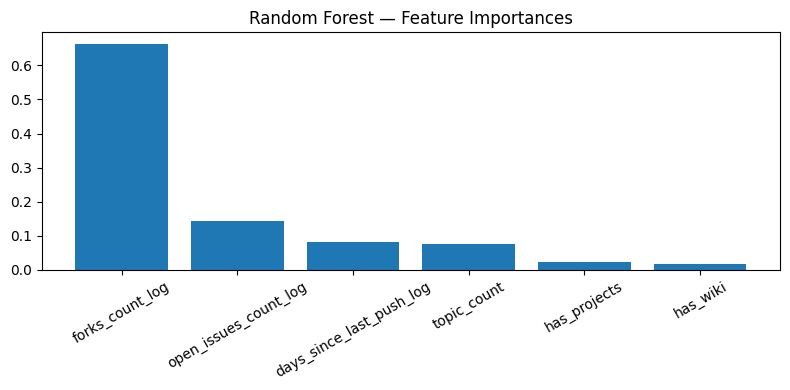

In [44]:
import matplotlib.pyplot as plt

feature_names = continuous_cols + boolean_cols

# For the best RF model
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 4))
plt.bar(range(len(feature_names)), importances[indices])
plt.xticks(range(len(feature_names)), [feature_names[i] for i in indices], rotation=30)
plt.title("Random Forest — Feature Importances")
plt.tight_layout()
plt.show()

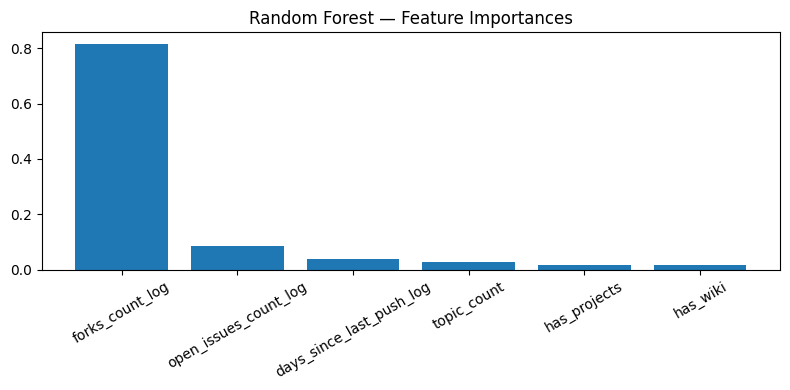

In [46]:
import matplotlib.pyplot as plt

feature_names = continuous_cols + boolean_cols

# For the best GB model
importances = best_gb.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 4))
plt.bar(range(len(feature_names)), importances[indices])
plt.xticks(range(len(feature_names)), [feature_names[i] for i in indices], rotation=30)
plt.title("Random Forest — Feature Importances")
plt.tight_layout()
plt.show()

In [47]:
results = pd.DataFrame({
    'Model':    ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'Baseline R²': [lr_r2, rf_r2, gb_r2],
    'Tuned R²':    [ridge_r2_tuned, rf_r2_tuned, gb_r2_tuned],
    'Improvement': [ridge_r2_tuned - lr_r2, rf_r2_tuned - rf_r2, gb_r2_tuned - gb_r2]
})
results = results.sort_values('Tuned R²', ascending=False).reset_index(drop=True)
display(results.round(4))


,Model,Baseline R²,Tuned R²,Improvement
0,Random Forest,0.2942,0.3463,0.0521
1,Linear Regression,0.3290,0.3278,-0.0012
2,Gradient Boosting,-0.0269,0.3088,0.3357


In [49]:
import joblib

y_test_actual = np.expm1(y_test)

models = {
    'Ridge':            (best_ridge, 'ridge_model.pkl'),
    'Random Forest':    (best_rf,    'rf_model.pkl'),
    'Gradient Boosting':(best_gb,    'gb_model.pkl'),
}

results_overfitting = []

for name, (model, filename) in models.items():
    train_r2 = r2_score(np.expm1(y_train), np.expm1(model.predict(X_train_scaled)))
    test_r2  = r2_score(y_test_actual,      np.expm1(model.predict(X_test_scaled)))
    gap      = train_r2 - test_r2

    results_overfitting.append({
        'Model':    name,
        'Train R²': round(train_r2, 4),
        'Test R²':  round(test_r2, 4),
        'Gap':      round(gap, 4),
        'Status':   '⚠ overfitting' if gap > 0.1 else '✓ ok'
    })

    joblib.dump(model, filename)
    print(f"Saved {name} → {filename}")

joblib.dump(preprocessor, 'preprocessor.pkl')
print("Saved preprocessor → preprocessor.pkl")

print("\n--- Overfitting Check ---")
display(pd.DataFrame(results_overfitting))

Saved Ridge → ridge_model.pkl
Saved Random Forest → rf_model.pkl
Saved Gradient Boosting → gb_model.pkl
Saved preprocessor → preprocessor.pkl

--- Overfitting Check ---


,Model,Train R²,Test R²,Gap,Status
0,Ridge,0.3425,0.3278,0.0147,✓ ok
1,Random Forest,0.7277,0.3463,0.3814,⚠ overfitting
2,Gradient Boosting,0.6596,0.3088,0.3508,⚠ overfitting


Summary:
Ridge Regression performed the best overall, despite no thaving the highest R2 scor eon the test set. Because predicting GitHub popularity is inherently noisy, Ridge's simplicity and penalty constraints allowed it to capture baseline trends without memorizing the noise.

Both Random Forest and Gradient Boosting struggled significantly. Because the dataset is small (1,000 rows) and GitHub star counts are highly volatile, these complex models overfit the training data. 

The best model achieved an R2 of 0.3290 (original linear regressino without L2 regularization). Only about 31% of a repository's popularity can be explained by structural metadata like forks, issues, and topics. 

To improve prediction accuracy in future iterations, the pipeline would need a vastly larger dataset or the integration of external viral features (e.g., social media mentions, Hacker News trends) that drive real-world GitHub popularity.